# Operational Demonstration of an Hourly Forecast

In this notebook, a previously evaluated temporal forecast is replayed as if the decision were being made at the beginning of an operational hour. The known profile is presented, actual demand is hidden, the E0 point forecast and U4b interval are provided, a simulated capacity is submitted to the decision rule, and only then is the observed value revealed.


In [1]:
import sys
from pathlib import Path
import warnings

PROJECT_ROOT = next(
    filter(
        lambda candidate: (
            (candidate / 'src').is_dir()
            and (candidate / 'notebooks').is_dir()
        ),
        (Path.cwd(), *Path.cwd().parents),
    )
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from matplotlib import pyplot as plt

from src import operational_demo_reports as reports
from src.i18n import make_lang
from src.operational_demo import (
    OperationalDemoConfig,
    build_operational_replay,
)
from src.plotting import set_graph_parameters

warnings.filterwarnings('ignore', category=FutureWarning)
set_graph_parameters()
plt.rcParams['axes.grid'] = False
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

lang = make_lang('en')


## 1. Objective and Scope of the Demonstration

The practical utility of the predictive system is demonstrated through a historical replay, not through a new validation. A single OOF observation from a selection fold under normal operating conditions is selected; it was already processed by Notebooks 06 and 07. No estimator is refitted, no new holdout prediction is produced, and no additional confirmatory conclusion is drawn.

Because demand is aggregated for the Seoul system, the decision is expressed as equivalent operational capacity, measured in rentals per hour. It cannot be inferred where bicycles should be positioned or how many physical units should be redistributed among stations, because the dataset contains neither inventory nor station-level geographic identifiers.


In [2]:
reports.environment_report(lang=lang)


,Item,Value
0,Conda environment,Bike-Sharing
1,Interpreter (sys.executable),Bike-Sharing/python.exe
2,Python version,3.10.20
3,Environment fingerprint,8f80d9216d47a792
4,Differences from environment.yml,none
5,Dependencies declared with the model,"mlflow==2.10.0, cloudpickle==3.1.2, numpy==1.2..."
6,scikit-learn,1.3.2
7,pandas,2.2.3
8,numpy,1.26.4
9,mlflow,2.10.0


## 2. Operational Replay Contract

The `full` execution of Notebook 07 is required as the source. Only predictions with an available interval, produced after warm-up and belonging to `selection` folds, are accepted; the 2020 stress regime and the final holdout are excluded by contract. The fixed seed makes the published example reproducible without manually choosing a favorable observation.

The capacity declared below is hypothetical and serves only to make the output actionable. It is not an observed variable in the dataset and does not participate in the forecast.


In [3]:
config = OperationalDemoConfig(
    candidate_id='U4b_g0p01',
    coverage=0.90,
    random_state=2026,
    planned_capacity=4000.0,
)
display(reports.protocol_report(config, lang=lang))


,Item,Value
0,Nature,historical replay of a frozen OOF forecast
1,Use of the final holdout,not used
2,Uncertainty candidate,U4b_g0p01
3,Nominal coverage,90%
4,Random-selection seed,2026
5,Simulated operational capacity,"4,000 rentals/hour"
6,Model refitting,none


## 3. Reproducible Temporal Selection

The observation is randomly selected from all rows eligible for the declared candidate and coverage. The target remains stored only for the subsequent audit; it is incorporated into neither the displayed profile nor the operational rule.


In [4]:
replay = build_operational_replay(config)
display(reports.selection_report(replay, lang=lang))


,Item,Value
0,Selected timestamp,10/22/2022 07:00
1,Temporal fold,4
2,Meteorological year,2022
3,Eligible rows,"34,322"
4,Calibrator history,"2,160 hours"
5,Adaptive alpha used,0.019


## 4. Profile Known at Forecast Time

Only information available at the beginning of the hour is displayed, including calendar attributes, rush-period regime, and weather conditions. Observed demand is deliberately omitted at this stage.


In [5]:
display(reports.profile_report(replay, lang=lang))


,Item,Value
0,Date and time,10/22/2022 07:00
1,Weekday,Saturday
2,Hour,7
3,Period,off-peak
4,Season,autumn
5,Rain,no rain
6,Temperature,10.6 °C
7,Humidity,86%
8,Wind speed,1.8 m/s
9,Visibility,795 m


## 5. Point Forecast and Prediction Interval

The central forecast was produced by Champion E0 in the corresponding temporal fold and preserved as a frozen OOF prediction. Around that center, `U4b_g0p01` was updated prequentially using only already observable residuals and provided the 90% interval, following the sequential adaptation principle discussed by Gibbs and Candès (2021).

Conformal coverage should be interpreted as an empirical marginal guarantee over the evaluated sequence. It is not claimed that this particular observation has exactly a 90% probability of lying within the interval.


In [6]:
display(reports.forecast_report(replay, lang=lang))


,Item,Value
0,E0 point forecast,"1,384 rentals/hour"
1,90% lower bound,0 rentals/hour
2,90% upper bound,"6,732 rentals/hour"
3,Interval width,"6,732 rentals/hour"


## 6. Decision Before Demand Is Revealed

The simulated capacity is compared first with the lower bound, then with the point forecast, and finally with the upper bound. When capacity lies between the point forecast and the upper bound, an attention zone is signaled, and the difference to the upper bound is presented as a conservative operational reserve.

The decision is made before actual demand is revealed, reproducing the information order that would exist in operation.


In [7]:
display(reports.decision_report(replay, lang=lang))


,Item,Value
0,Simulated operational capacity,"4,000 rentals/hour"
1,Decision,ATTENTION ZONE
2,Additional capacity up to the point forecast,0 rentals/hour
3,Additional reserve up to the upper bound,"2,732 rentals/hour"


## 7. Revelation and Audit

Only after the forecast and decision have been recorded is the observed demand revealed. The point error, interval coverage, and capacity satisfaction with the volume realized are verified. This separation prevents the operational narrative from being constructed retrospectively from the known result.


In [8]:
display(reports.audit_report(replay, lang=lang))


,Item,Value
0,Demand observed after the decision,"2,469"
1,Point forecast absolute error,"1,085"
2,Actual value contained within the interval,yes
3,Simulated capacity would have served demand,yes


## 8. Visual Interpretation of the Decision

The central forecast, interval, declared capacity, and subsequently observed demand are positioned on the same scale. Thus, the point error can be distinguished from the operational uncertainty that would need to be absorbed. The width and coverage are read together, in accordance with the evaluation of probabilistic forecast proposed by Gneiting and Raftery (2007).


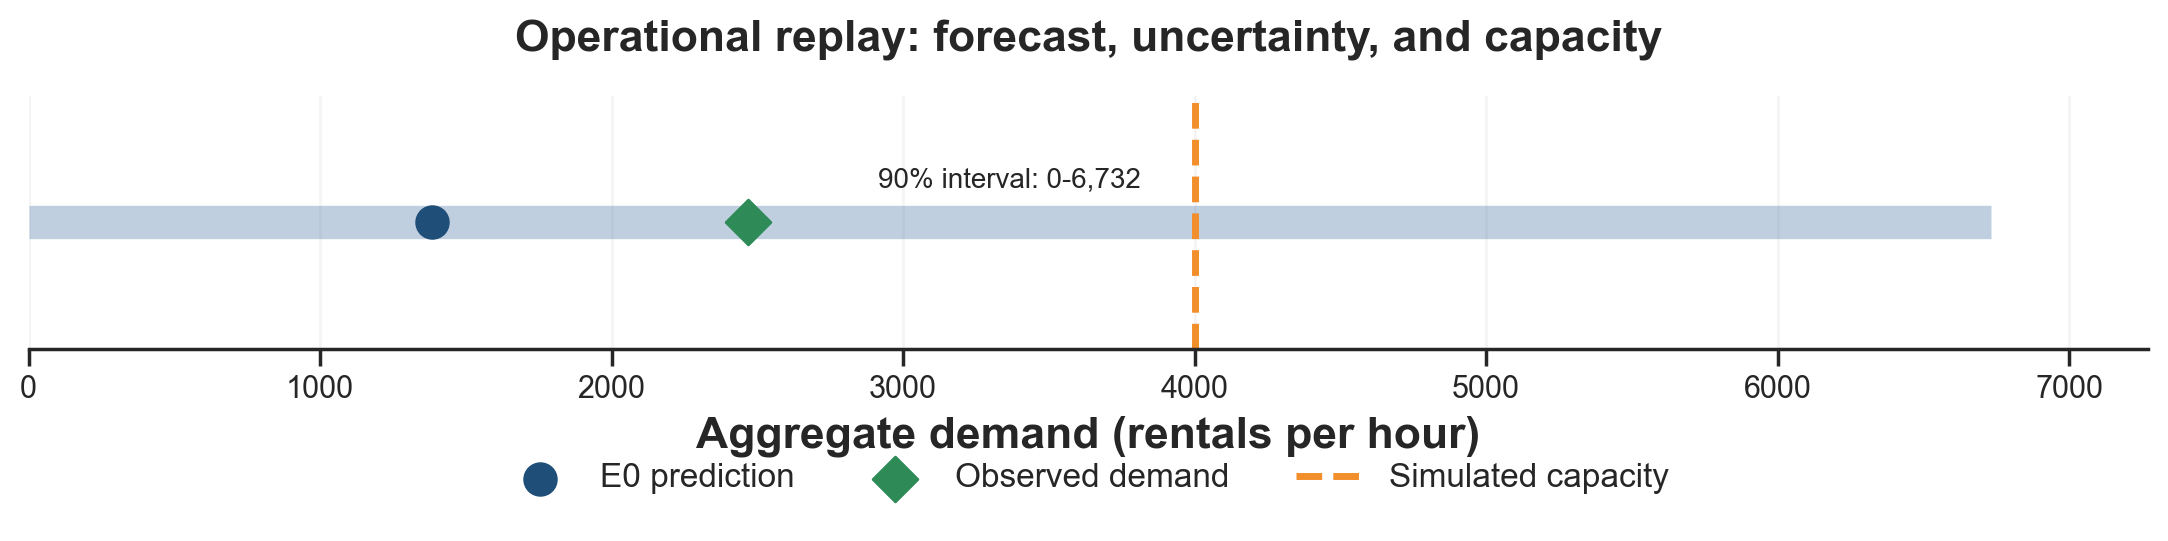

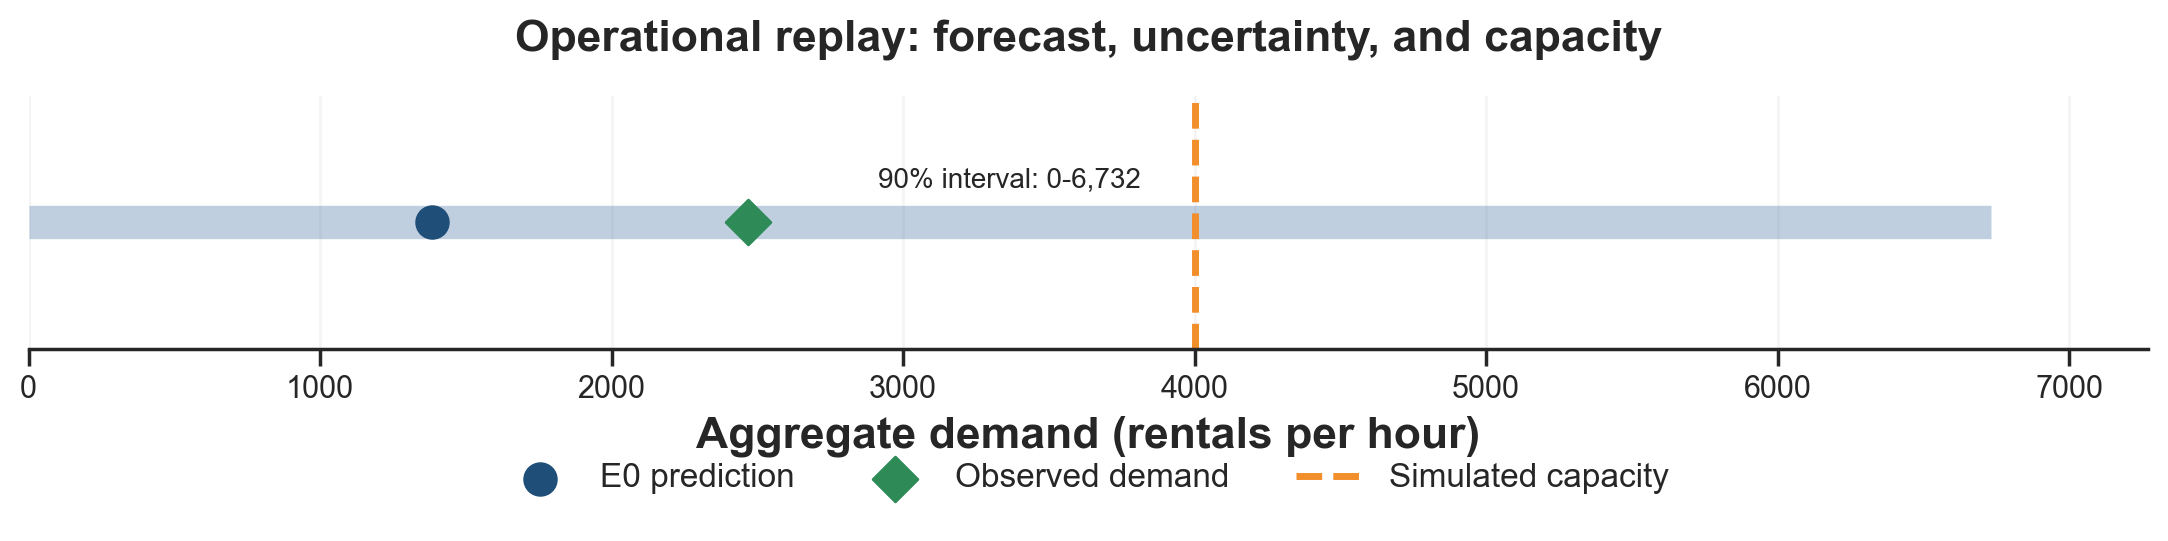

In [9]:
reports.plot_operational_forecast(replay, lang=lang)


### Insights

>At the selected time, October 22, 2022 at 7:00 a.m., E0 forecast 1,384 rentals and U4b produced a 90% interval from 0 to 6,732. The simulated operational capacity of 4,000 rentals/hour exceeded the point forecast but remained 2,732 below the upper bound. An attention zone was therefore signaled instead of classifying capacity as immediately sufficient.
>
>The actual demand of 2,469 rentals was revealed only after the decision. The point forecast underestimated demand by 1,085 rentals, or 43.9% of the realized volume, but the actual value was contained within the interval and would have been served by the simulated capacity. The uncertainty layer thus communicated a relevant deviation that the point forecast alone would not have shown to the person responsible for the operation.
>
>The interval width of 6,732 rentals must also be considered. Although coverage was achieved in this case, the lower bound truncated at zero and the high upper bound produced a conservative and potentially costly recommendation. The example confirms the interval's usefulness for signaling risk, while also making tangible the conditional limitation identified in Notebook 07: a large reserve may still be required in locally difficult regimes.
>
>The demonstration remains limited to aggregated rentals-per-hour planning. A station-level rebalancing policy cannot be derived, and the reserve up to the upper bound should not be interpreted automatically as a physical number of bicycles. Such an extension would require inventory, returns, station locations, and repositioning times.


## 9. Synthesis

A reproducible operational demonstration was implemented without violating the validation boundary. The observation was randomly selected from selection-fold OOF predictions, the profile was presented without the target, capacity was declared as an external hypothesis, and the decision was recorded before demand was revealed.

In the executed example, the forecast of 1,384 rentals was compared with the interval from 0 to 6,732 and with a simulated capacity of 4,000 rentals/hour. Before demand was known, an attention zone was recorded and a conservative reserve of 2,732 rentals/hour was quantified. After the reveal, the demand of 2,469 rentals was found to have been underestimated by the point forecast by 1,085 rentals, while remaining within the interval and below the simulated capacity.

The practical value of the system was shifted from an isolated numerical forecast to a decision conditioned on uncertainty. This makes it possible to estimate not only the expected central volume, but also how much additional capacity would be required to reach a conservative operational bound. The gain is presented not as the elimination of risk, but as its measurable disclosure. The large width observed in this replay was also preserved in the narrative because local coverage was obtained through an operationally costly range.

The forecast used here remains historical and OOF. Truly online inference would require the E0 pipeline, E4 scale producer, and U4b state to be frozen and versioned together. During the first 168 hours, the point forecast could be produced, but the conformal interval would remain unavailable until the minimum residual history had been observed.


In [10]:
print(reports.synthesis_report(replay, lang=lang))


For 10/22/2022 07:00, E0 forecast 1,384 rentals/hour and U4b produced the interval [0, 6,732]. The simulated operational capacity of 4,000 was classified as ATTENTION ZONE. After the reveal, the observed demand of 2,469 was contained within the interval, and the simulated capacity would have served the realized volume.


## 10. Provenance and Reproducibility

The hashes of the consumed artifacts are presented so that the example can be associated with the conformal predictions and the dataset that originated it. The seed, candidate, coverage, and simulated capacity remain declared in the notebook configuration.


In [11]:
reports.source_audit_report(replay, lang=lang)


,Artifact,Path,Bytes,SHA-256
0,conformal_manifest,dataset/normal_operations/conformal_uncertaint...,11113,962936e913081abaf494f5c681f1aefd5872f8f9ff5386...
1,conformal_predictions,dataset/normal_operations/conformal_uncertaint...,73119286,806965fa438dc9ec5b60af57ea91b5ad5a59c72e803e9d...
2,raw_context,dataset/Seoul_public_bicycle.csv,7410678,62e174f067481a55f8beb4fa44df97cc362be2ef766a57...


### Methodological References

Gibbs, I.; Candès, E. J. (2021). Adaptive Conformal Inference Under Distribution Shift. Advances in Neural Information Processing Systems, 34, 1660–1672.

Gneiting, T.; Raftery, A. E. (2007). Strictly Proper Scoring Rules, Prediction, and Estimation. Journal of the American Statistical Association, 102(477), 359–378.
